**Dataset:** Cassava Leaf Disease (Plant Leaf Diseases Training Dataset — Group 7)  
**Models:** Custom CNN | DenseNet121 | ResNet50 | InceptionV3  
**Train-Test Split:** test_size=0.26, random_state=27

---
## SECTION 1 — Setup & Imports

In [1]:
import os
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121, ResNet50, InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, accuracy_score
)
from sklearn.preprocessing import label_binarize
from itertools import cycle

print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

2026-04-07 20:11:12.406642: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775592672.563885      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775592672.609471      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775592672.961531      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775592672.961575      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775592672.961578      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


---
## SECTION 2 — Global Configuration

In [2]:
# ══════════════════════════════════════════════════════
#  Registration: 20EGCO1427  |  XY = 27
#  test_size  = ((87*0.05)+25)/100 = 0.26
#  random_state = 87
# ══════════════════════════════════════════════════════
RANDOM_STATE = 27
TEST_SIZE    = 0.29
IMG_SIZE     = (224, 224)
INPUT_SHAPE  = (224, 224, 3)
BATCH_SIZE   = 32
EPOCHS       = 2
NUM_CLASSES  = 5

SHORT_NAMES  = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']
FULL_NAMES   = [
    'Cassava Bacterial Blight',
    'Cassava Brown Streak Disease',
    'Cassava Green Mottle',
    'Cassava Mosaic Disease',
    'Healthy'
]

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Storage for all results
ALL_RESULTS  = {}
ALL_HISTORIES = {}

print('Global config set.')

Global config set.


---
## SECTION 3 — Dataset Loading & Exploration

In [3]:
BASE_PATH = '/kaggle/input/datasets/nirmalsankalana/plant-diseases-training-dataset'

# Print top-level folders
print('Top-level folders:')
for f in sorted(os.listdir(BASE_PATH)):
    print(' -', f)

# Find Cassava folder
CASSAVA_PATH = None
for root, dirs, files in os.walk(BASE_PATH):
    if 'cassava' in root.lower():
        print('\nFound:', root, '|', len(files), 'files')
        if CASSAVA_PATH is None:
            CASSAVA_PATH = root

Top-level folders:
 - data
 - index.txt

Found: /kaggle/input/datasets/nirmalsankalana/plant-diseases-training-dataset/data/Cassava___mosaic_disease | 13158 files

Found: /kaggle/input/datasets/nirmalsankalana/plant-diseases-training-dataset/data/Cassava___brown_streak_disease | 2189 files

Found: /kaggle/input/datasets/nirmalsankalana/plant-diseases-training-dataset/data/Cassava___bacterial_blight | 1087 files

Found: /kaggle/input/datasets/nirmalsankalana/plant-diseases-training-dataset/data/Cassava___green_mottle | 2386 files

Found: /kaggle/input/datasets/nirmalsankalana/plant-diseases-training-dataset/data/Cassava___healthy | 2577 files


In [4]:
# Correct CASSAVA_PATH — point to the 'data' folder, not inside a class
CASSAVA_PATH = BASE_PATH + '/data'

# Now list the actual classes
print('Classes found:')
total = 0
for c in sorted(os.listdir(CASSAVA_PATH)):
    full_path = os.path.join(CASSAVA_PATH, c)
    if os.path.isdir(full_path):          # only count folders, skip stray files
        count = len(os.listdir(full_path))
        print(f'  {c}: {count} images')
        total += count

print(f'\nTotal images: {total}')

Classes found:
  Apple___alternaria_leaf_spot: 278 images
  Apple___black_rot: 621 images
  Apple___brown_spot: 215 images
  Apple___gray_spot: 395 images
  Apple___healthy: 2570 images
  Apple___rust: 1241 images
  Apple___scab: 1222 images
  Bell_pepper___bacterial_spot: 997 images
  Bell_pepper___healthy: 1478 images
  Blueberry___healthy: 1502 images
  Cassava___bacterial_blight: 1087 images
  Cassava___brown_streak_disease: 2189 images
  Cassava___green_mottle: 2386 images
  Cassava___healthy: 2577 images
  Cassava___mosaic_disease: 13158 images
  Cherry___healthy: 854 images
  Cherry___powdery_mildew: 1052 images
  Coffee___healthy: 791 images
  Coffee___red_spider_mite: 167 images
  Coffee___rust: 602 images
  Corn___common_rust: 1192 images
  Corn___gray_leaf_spot: 513 images
  Corn___healthy: 1162 images
  Corn___northern_leaf_blight: 985 images
  Grape___Leaf_blight: 1076 images
  Grape___black_measles: 2671 images
  Grape___black_rot: 1580 images
  Grape___healthy: 1705 imag

In [5]:
# Check working folder
print('=== /kaggle/working/ ===')
for f in os.listdir('/kaggle/working/'):
    full = os.path.join('/kaggle/working/', f)
    kind = 'DIR' if os.path.isdir(full) else 'FILE'
    print(f'  [{kind}] {f}')

# Check input folder
print('\n=== /kaggle/input/ ===')
for f in os.listdir('/kaggle/input/'):
    print(f'  {f}')

# Check cassava_only specifically
print('\n=== cassava_only exists?', os.path.exists('/kaggle/working/cassava_only'), '===')
if os.path.exists('/kaggle/working/cassava_only'):
    for f in os.listdir('/kaggle/working/cassava_only'):
        print(f'  {f}')

=== /kaggle/working/ ===
  [DIR] .virtual_documents

=== /kaggle/input/ ===
  datasets

=== cassava_only exists? False ===


In [6]:
CASSAVA_ONLY_PATH = '/kaggle/working/cassava_only'
os.makedirs(CASSAVA_ONLY_PATH, exist_ok=True)

cassava_folders = [
    'Cassava___bacterial_blight',
    'Cassava___brown_streak_disease',
    'Cassava___green_mottle',
    'Cassava___healthy',
    'Cassava___mosaic_disease'
]

source = '/kaggle/input/datasets/nirmalsankalana/plant-diseases-training-dataset/data'

for folder in cassava_folders:
    src = os.path.join(source, folder)
    dst = os.path.join(CASSAVA_ONLY_PATH, folder)
    if not os.path.exists(dst):
        shutil.copytree(src, dst)
    print(f'✓ Copied: {folder}')

# Update all path variables
CASSAVA_PATH = CASSAVA_ONLY_PATH
NUM_CLASSES  = 5

print(f'\nCASSAVA_PATH = {CASSAVA_PATH}')
print('Classes:')
for f in sorted(os.listdir(CASSAVA_PATH)):
    count = len(os.listdir(os.path.join(CASSAVA_PATH, f)))
    print(f'  {f}: {count} images')

✓ Copied: Cassava___bacterial_blight
✓ Copied: Cassava___brown_streak_disease
✓ Copied: Cassava___green_mottle
✓ Copied: Cassava___healthy
✓ Copied: Cassava___mosaic_disease

CASSAVA_PATH = /kaggle/working/cassava_only
Classes:
  Cassava___bacterial_blight: 1087 images
  Cassava___brown_streak_disease: 2189 images
  Cassava___green_mottle: 2386 images
  Cassava___healthy: 2577 images
  Cassava___mosaic_disease: 13158 images


In [7]:
# Build class_counts from the copied folder
class_counts = {}
for cls in sorted(os.listdir(CASSAVA_PATH)):
    full_path = os.path.join(CASSAVA_PATH, cls)
    if os.path.isdir(full_path):
        class_counts[cls] = len(os.listdir(full_path))

# Clean short names for display
display_names = {
    'Cassava___bacterial_blight'    : 'Bacterial Blight',
    'Cassava___brown_streak_disease': 'Brown Streak',
    'Cassava___green_mottle'        : 'Green Mottle',
    'Cassava___healthy'             : 'Healthy',
    'Cassava___mosaic_disease'      : 'Mosaic Disease'
}

labels = [display_names[k] for k in class_counts.keys()]
values = list(class_counts.values())
print("class_counts has been registered in memory ")

class_counts has been registered in memory 


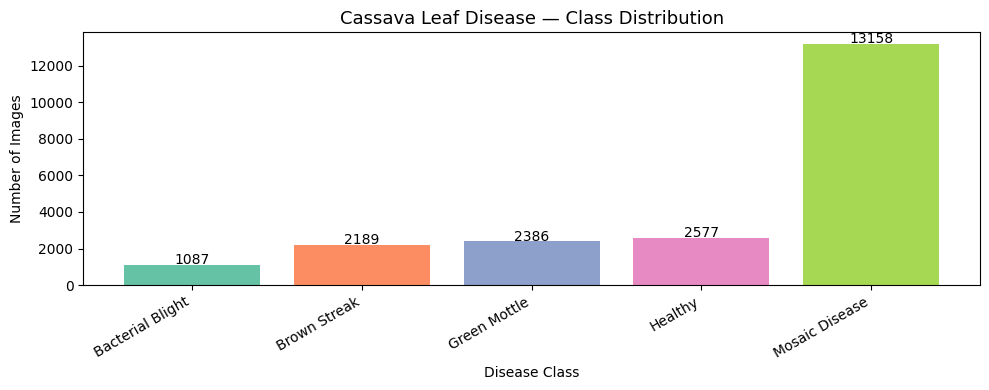

In [8]:
# Plot class distribution

# Plot
plt.figure(figsize=(10, 4))
bars = plt.bar(labels, values, color=sns.color_palette('Set2', len(class_counts)))
plt.title('Cassava Leaf Disease — Class Distribution', fontsize=13)
plt.xlabel('Disease Class'); plt.ylabel('Number of Images')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## SECTION 4 — Data Generators

In [9]:
# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=TEST_SIZE   # 0.26
)

# Validation generator — NO augmentation, only rescale
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=TEST_SIZE
)

def make_generators(path=CASSAVA_PATH):
    train_gen = train_datagen.flow_from_directory(
        path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='training',
        seed=RANDOM_STATE, shuffle=True
    )
    val_gen = val_datagen.flow_from_directory(
        path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='validation',
        seed=RANDOM_STATE, shuffle=False
    )
    return train_gen, val_gen

train_gen, val_gen = make_generators()
print(f'Training   : {train_gen.samples} samples')
print(f'Validation : {val_gen.samples} samples')
print(f'Class map  : {train_gen.class_indices}')

Found 15835 images belonging to 5 classes.
Found 5562 images belonging to 5 classes.
Training   : 15835 samples
Validation : 5562 samples
Class map  : {'Cassava___bacterial_blight': 0, 'Cassava___brown_streak_disease': 1, 'Cassava___green_mottle': 2, 'Cassava___healthy': 3, 'Cassava___mosaic_disease': 4}


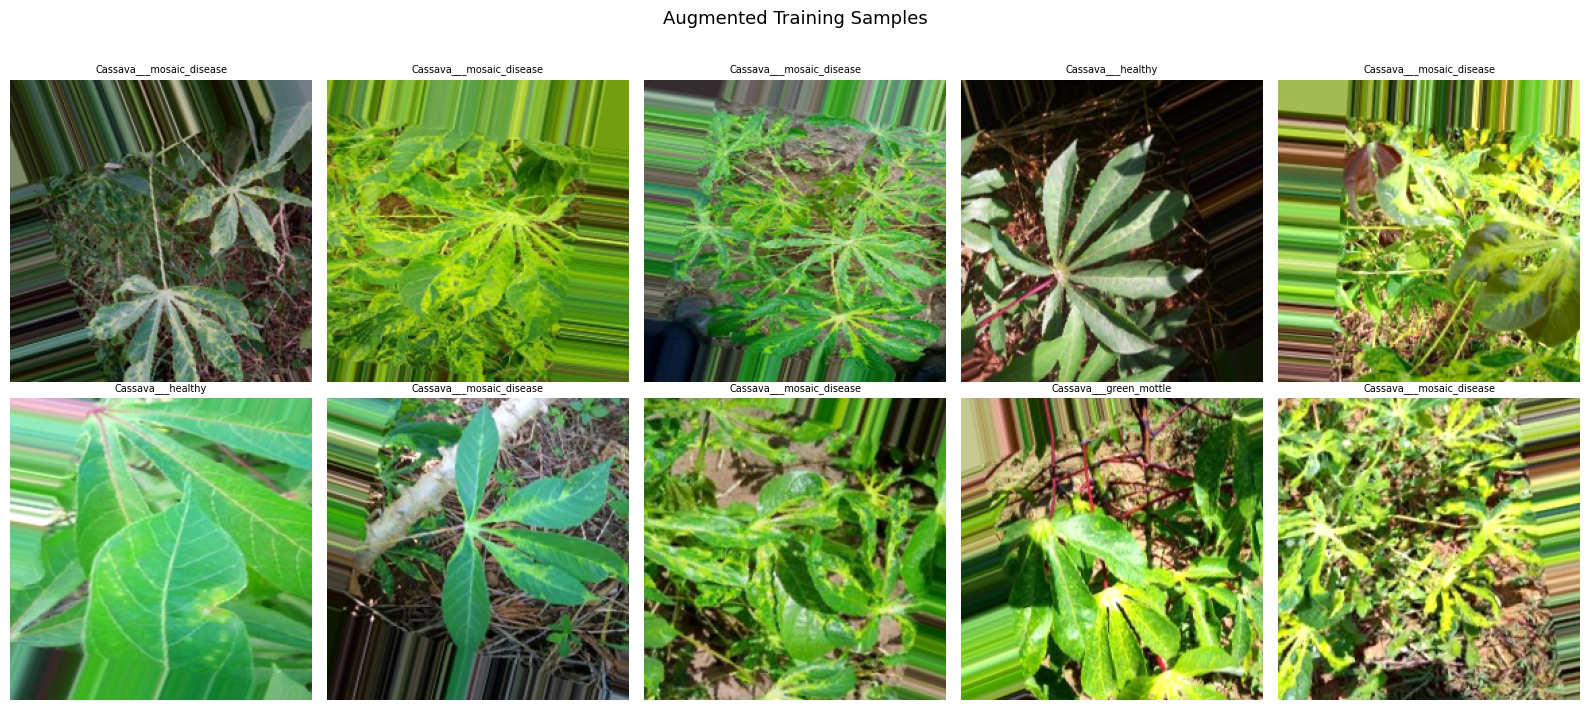

In [10]:
# Visualise augmented samples
imgs, labels = next(train_gen)
label_map = {v: k for k, v in train_gen.class_indices.items()}

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    ax.set_title(label_map[np.argmax(labels[i])], fontsize=7)
    ax.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## SECTION 5 — Helper Functions

In [11]:
def get_callbacks(name):
    return [
        EarlyStopping(
            monitor='val_loss', patience=7,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=4, min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            f'{name}_best.h5', monitor='val_accuracy',
            save_best_only=True, verbose=0
        )
    ]


def plot_history(history, model_name, phase_split=None):
    """Plot accuracy and loss curves."""
    h = history if isinstance(history, dict) else history.history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, ylabel in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
        ax.plot(h[metric],         label=f'Train {ylabel}', linewidth=2)
        ax.plot(h[f'val_{metric}'],label=f'Val {ylabel}',   linewidth=2)
        if phase_split:
            ax.axvline(phase_split, color='gray', linestyle='--',
                       alpha=0.7, label='Fine-tune start')
        ax.set_title(f'{model_name} — {ylabel} Curve')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def evaluate_model(model, val_generator, model_name):
    """Full evaluation: metrics + confusion matrix + ROC + PR curves."""
    val_generator.reset()
    y_prob = model.predict(val_generator, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = val_generator.classes
    y_bin  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    roc  = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
    pr   = average_precision_score(y_bin, y_prob, average='macro')

    print(f'\n{"="*55}')
    print(f'  {model_name} — Results')
    print(f'{"="*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {roc:.4f}')
    print(f'  PR-AUC    : {pr:.4f}')
    print(f'  Parameters: {model.count_params():,}')

    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=SHORT_NAMES))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES)
    plt.title(f'{model_name} — Confusion Matrix', fontsize=13)
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout(); plt.show()

    # ROC Curves per class
    from sklearn.metrics import roc_curve
    plt.figure(figsize=(8, 6))
    colors = cycle(['#e74c3c','#3498db','#2ecc71','#9b59b6','#f39c12'])
    for i, (color, name) in enumerate(zip(colors, SHORT_NAMES)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        auc_i = roc_auc_score(y_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_i:.2f})')
    plt.plot([0,1],[0,1],'k--', lw=1)
    plt.xlim([0,1]); plt.ylim([0,1.02])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} — ROC Curves')
    plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # PR Curves per class
    from sklearn.metrics import precision_recall_curve
    plt.figure(figsize=(8, 6))
    colors = cycle(['#e74c3c','#3498db','#2ecc71','#9b59b6','#f39c12'])
    for i, (color, name) in enumerate(zip(colors, SHORT_NAMES)):
        p, r, _ = precision_recall_curve(y_bin[:, i], y_prob[:, i])
        ap = average_precision_score(y_bin[:, i], y_prob[:, i])
        plt.plot(r, p, color=color, lw=2, label=f'{name} (AP={ap:.2f})')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(f'{model_name} — Precision-Recall Curves')
    plt.legend(loc='upper right'); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # Save model & get size
    save_path = f'{model_name.replace(" ","_")}.h5'
    model.save(save_path)
    size_mb = os.path.getsize(save_path) / (1024*1024)
    print(f'  Model Size: {size_mb:.2f} MB')

    return {
        'Model'      : model_name,
        'Accuracy'   : round(acc,  4),
        'Precision'  : round(prec, 4),
        'Recall'     : round(rec,  4),
        'F1-Score'   : round(f1,   4),
        'ROC-AUC'    : round(roc,  4),
        'PR-AUC'     : round(pr,   4),
        'Parameters' : f'{model.count_params():,}',
        'Size (MB)'  : round(size_mb, 2)
    }


def build_pretrained(base_class, model_name, freeze_base=True):
    """Build a pretrained model with a custom head using Functional API."""
    base = base_class(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
    base.trainable = not freeze_base

    inputs  = keras.Input(shape=INPUT_SHAPE)
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(512, activation='relu',
                           kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x       = layers.Dropout(0.5)(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=model_name)
    return model, base


def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined


print('Helper functions ready.')

Helper functions ready.


---
## SECTION 6 — MODEL 1: Custom CNN (Keras Sequential API)

In [12]:
print('Building Custom CNN...')

custom_cnn = keras.Sequential([
    # ── Block 1 ──
    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=INPUT_SHAPE),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # ── Block 2 ──
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # ── Block 3 ──
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # ── Block 4 ──
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # ── Classifier Head ──
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu',
                 kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='Custom_CNN')

custom_cnn.summary()

Building Custom CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775592917.185441      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775592917.191433      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,442,341 (5.50 MB)

 Trainable params: 1,439,397 (5.49 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [13]:
train_gen, val_gen = make_generators()

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Training Custom CNN...')
hist_custom = custom_cnn.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks('custom_cnn'),
    verbose=1
)
ALL_HISTORIES['Custom CNN'] = hist_custom.history

Found 15835 images belonging to 5 classes.
Found 5562 images belonging to 5 classes.
Training Custom CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2


I0000 00:00:1775592926.215656     149 service.cc:152] XLA service 0x7f4eb010e250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775592926.215710     149 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775592926.215715     149 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775592927.395808     149 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-07 20:15:34.043916: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 20:15:34.198154: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 20:15:37.222447: E external/local_xl

 37/495 ━━━━━━━━━━━━━━━━━━━━ 3:00 394ms/step - accuracy: 0.4297 - loss: 2.2765

2026-04-07 20:16:11.031714: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 20:16:11.185031: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 20:16:14.066317: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 20:16:14.359491: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.5134 - loss: 1.9852

495/495 ━━━━━━━━━━━━━━━━━━━━ 277s 499ms/step - accuracy: 0.5135 - loss: 1.9848 - val_accuracy: 0.6127 - val_loss: 1.4371 - learning_rate: 0.0010
Epoch 2/2
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.6059 - loss: 1.4289

495/495 ━━━━━━━━━━━━━━━━━━━━ 217s 438ms/step - accuracy: 0.6059 - loss: 1.4288 - val_accuracy: 0.6415 - val_loss: 1.3435 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.


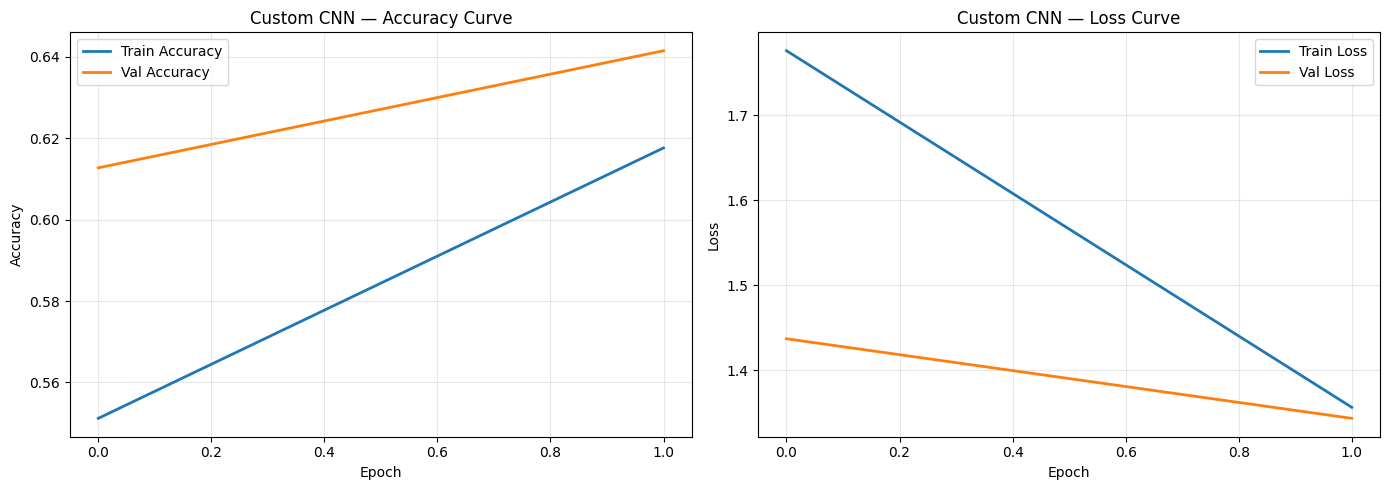

In [14]:
plot_history(hist_custom, 'Custom CNN')

Found 15835 images belonging to 5 classes.
Found 5562 images belonging to 5 classes.
174/174 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step

  Custom CNN — Results
  Accuracy  : 0.6415
  Precision : 0.4911
  Recall    : 0.6415
  F1-Score  : 0.5381
  ROC-AUC   : 0.7026
  PR-AUC    : 0.3271
  Parameters: 1,442,341

Classification Report:
              precision    recall  f1-score   support

         CBB       0.38      0.20      0.26       282
        CBSD       0.37      0.24      0.29       569
         CGM       0.00      0.00      0.00       620
         CMD       0.16      0.01      0.02       670
     Healthy       0.67      0.98      0.80      3421

    accuracy                           0.64      5562
   macro avg       0.32      0.29      0.27      5562
weighted avg       0.49      0.64      0.54      5562



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


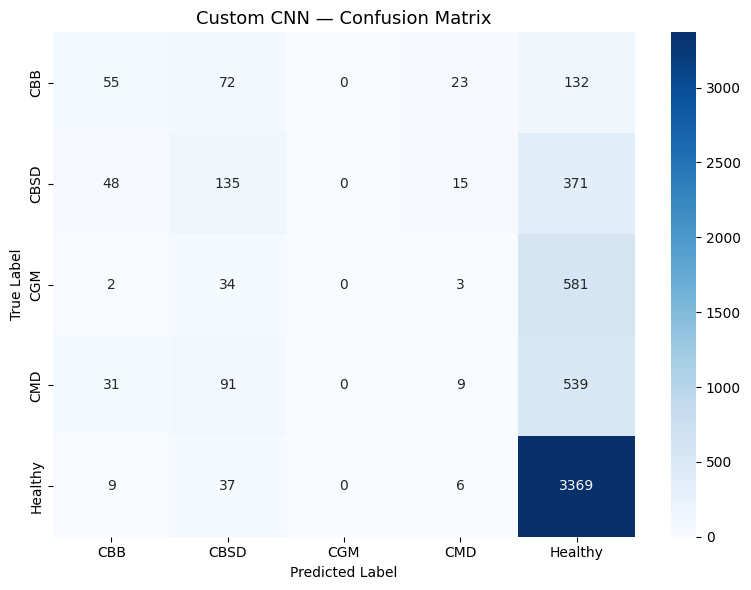

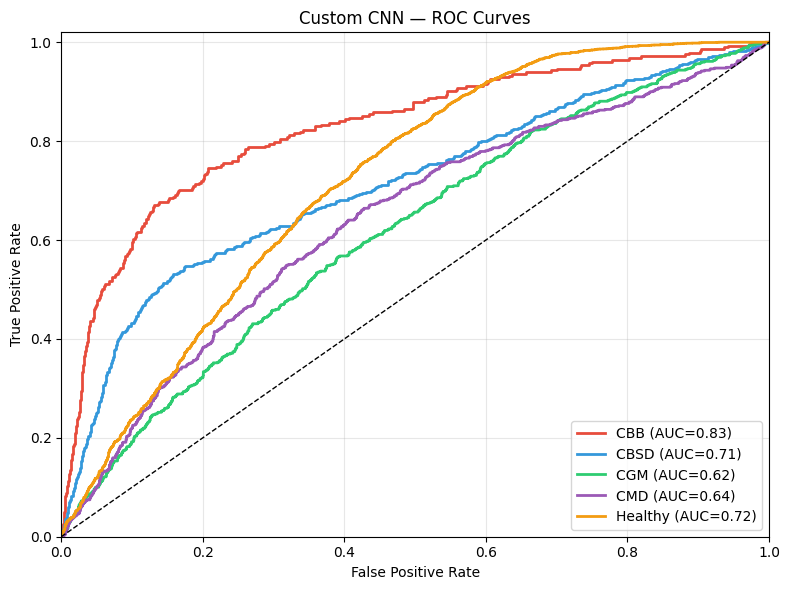

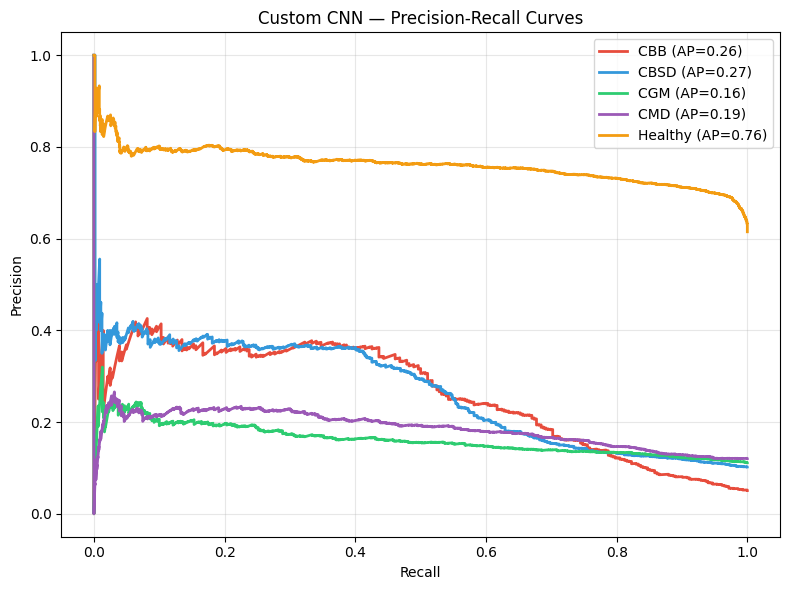

  Model Size: 16.65 MB


In [15]:
train_gen, val_gen = make_generators()
result_custom = evaluate_model(custom_cnn, val_gen, 'Custom CNN')
ALL_RESULTS['Custom CNN'] = result_custom

---
## SECTION 7 — MODEL 2: DenseNet121 (Pretrained, Functional API)

In [16]:
print('Building DenseNet121...')
densenet_model, densenet_base = build_pretrained(DenseNet121, 'DenseNet121')
densenet_model.summary()

Building DenseNet121...
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,699,013 (29.37 MB)

 Trainable params: 659,461 (2.52 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [17]:
train_gen, val_gen = make_generators()

# Phase 1: Train head only
densenet_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy']
)
print('DenseNet121 Phase 1: Head training...')
hist_dn_p1 = densenet_model.fit(
    train_gen, epochs=10, validation_data=val_gen,
    callbacks=get_callbacks('densenet_p1'), verbose=1
)

# Phase 2: Fine-tune last 60 layers
densenet_base.trainable = True
for layer in densenet_base.layers[:-60]:
    layer.trainable = False

densenet_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy', metrics=['accuracy']
)
print('DenseNet121 Phase 2: Fine-tuning...')
hist_dn_p2 = densenet_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=get_callbacks('densenet_p2'), verbose=1
)

ALL_HISTORIES['DenseNet121'] = combine_histories(hist_dn_p1, hist_dn_p2)
phase_split_dn = len(hist_dn_p1.history['accuracy'])

Found 15835 images belonging to 5 classes.
Found 5562 images belonging to 5 classes.
DenseNet121 Phase 1: Head training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.6278 - loss: 1.5599

495/495 ━━━━━━━━━━━━━━━━━━━━ 285s 517ms/step - accuracy: 0.6278 - loss: 1.5595 - val_accuracy: 0.7116 - val_loss: 1.1301 - learning_rate: 0.0010
Epoch 2/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.6834 - loss: 1.1833

495/495 ━━━━━━━━━━━━━━━━━━━━ 216s 436ms/step - accuracy: 0.6834 - loss: 1.1832 - val_accuracy: 0.7240 - val_loss: 1.0046 - learning_rate: 0.0010
Epoch 3/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.6995 - loss: 1.0864

...

495/495 ━━━━━━━━━━━━━━━━━━━━ 218s 441ms/step - accuracy: 0.7098 - loss: 0.9633 - val_accuracy: 0.7436 - val_loss: 0.8719 - learning_rate: 0.0010
Epoch 7/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.7105 - loss: 0.9537

495/495 ━━━━━━━━━━━━━━━━━━━━ 218s 441ms/step - accuracy: 0.7105 - loss: 0.9537 - val_accuracy: 0.7443 - val_loss: 0.8600 - learning_rate: 0.0010
Epoch 8/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 217s 438ms/step - accuracy: 0.7122 - loss: 0.9446 - val_accuracy: 0.7384 - val_loss: 0.8778 - learning_rate: 0.0010
Epoch 9/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.7205 - loss: 0.9273

495/495 ━━━━━━━━━━━━━━━━━━━━ 217s 438ms/step - accuracy: 0.7205 - loss: 0.9274 - val_accuracy: 0.7474 - val_loss: 0.8642 - learning_rate: 0.0010
Epoch 10/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 221s 446ms/step - accuracy: 0.7041 - loss: 0.9562 - val_accuracy: 0.7389 - val_loss: 0.8941 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 7.
DenseNet121 Phase 2: Fine-tuning...
Epoch 1/2
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.7157 - loss: 0.9530

495/495 ━━━━━━━━━━━━━━━━━━━━ 297s 520ms/step - accuracy: 0.7157 - loss: 0.9530 - val_accuracy: 0.7452 - val_loss: 0.8604 - learning_rate: 1.0000e-05
Epoch 2/2
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.7158 - loss: 0.9310

495/495 ━━━━━━━━━━━━━━━━━━━━ 218s 439ms/step - accuracy: 0.7158 - loss: 0.9310 - val_accuracy: 0.7481 - val_loss: 0.8510 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 2.


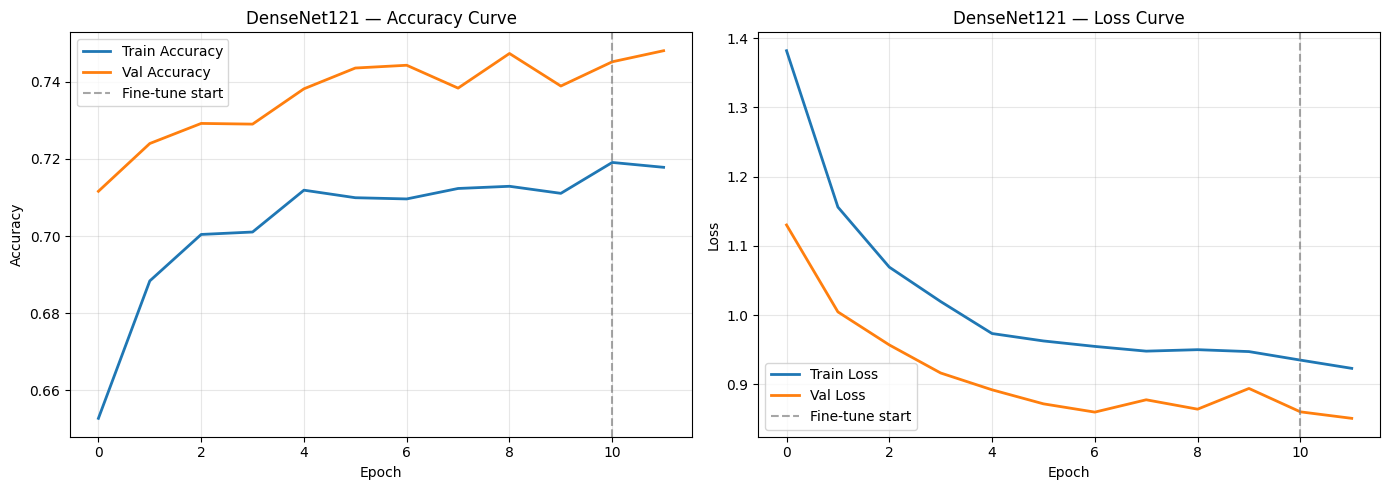

In [18]:
plot_history(ALL_HISTORIES['DenseNet121'], 'DenseNet121', phase_split=phase_split_dn)

Found 15835 images belonging to 5 classes.
Found 5562 images belonging to 5 classes.
174/174 ━━━━━━━━━━━━━━━━━━━━ 37s 148ms/step

  DenseNet121 — Results
  Accuracy  : 0.7481
  Precision : 0.7427
  Recall    : 0.7481
  F1-Score  : 0.7376
  ROC-AUC   : 0.8995
  PR-AUC    : 0.6160
  Parameters: 7,699,013

Classification Report:
              precision    recall  f1-score   support

         CBB       0.48      0.49      0.49       282
        CBSD       0.62      0.46      0.52       569
         CGM       0.62      0.33      0.43       620
         CMD       0.47      0.61      0.53       670
     Healthy       0.86      0.92      0.89      3421

    accuracy                           0.75      5562
   macro avg       0.61      0.56      0.57      5562
weighted avg       0.74      0.75      0.74      5562



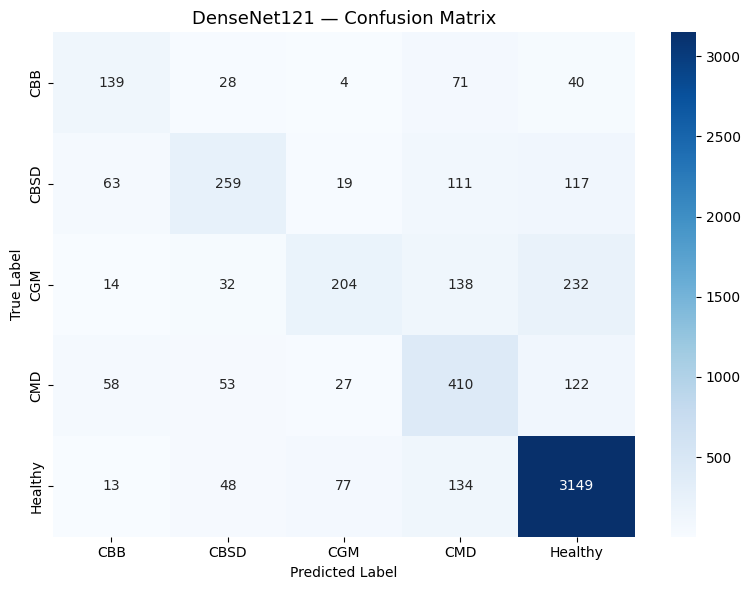

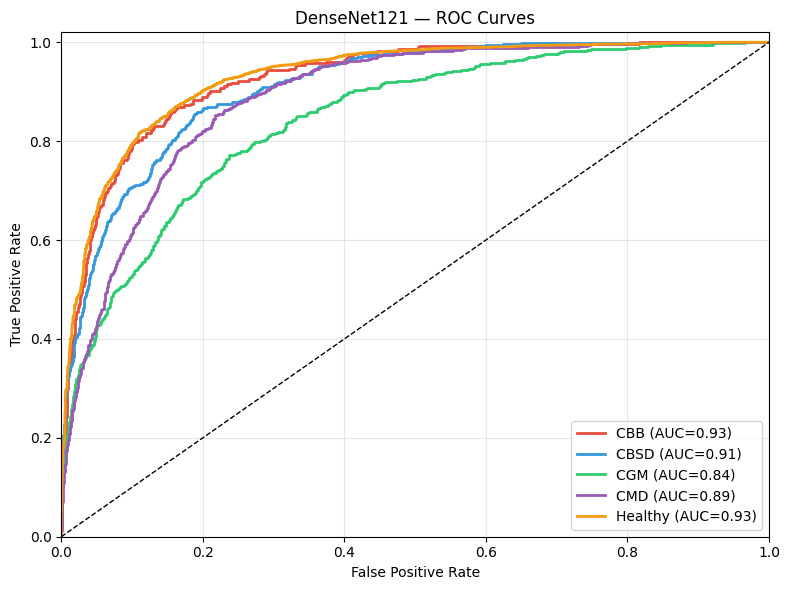

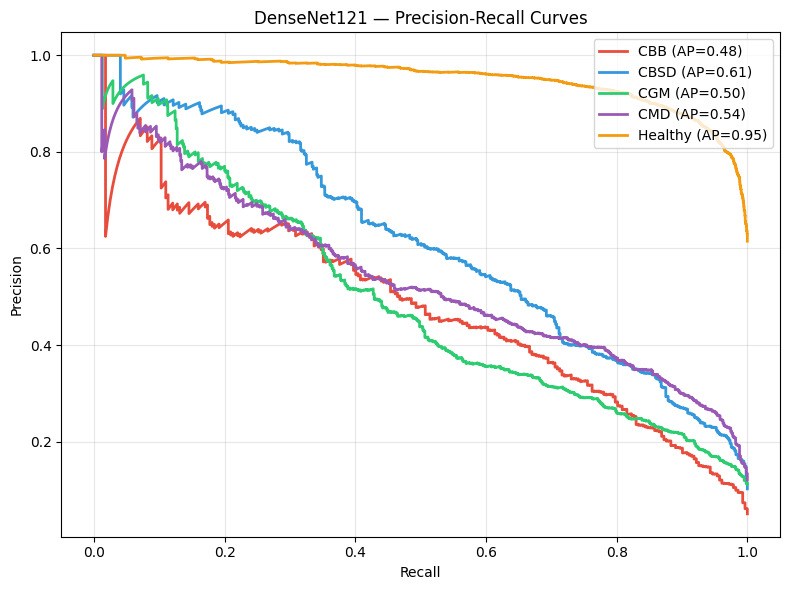

  Model Size: 44.82 MB


In [19]:
train_gen, val_gen = make_generators()
result_densenet = evaluate_model(densenet_model, val_gen, 'DenseNet121')
ALL_RESULTS['DenseNet121'] = result_densenet

---
## SECTION 8 — MODEL 3: ResNet50 (Pretrained, Functional API)

In [20]:
print('Building ResNet50...')
resnet_model, resnet_base = build_pretrained(ResNet50, 'ResNet50')
resnet_model.summary()

Building ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,777,605 (94.52 MB)

 Trainable params: 1,185,797 (4.52 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [21]:
train_gen, val_gen = make_generators()

# Phase 1
resnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy']
)
print('ResNet50 Phase 1: Head training...')
hist_rn_p1 = resnet_model.fit(
    train_gen, epochs=2, validation_data=val_gen,
    callbacks=get_callbacks('resnet_p1'), verbose=1
)

# Phase 2: Fine-tune last 40 layers
resnet_base.trainable = True
for layer in resnet_base.layers[:-40]:
    layer.trainable = False

resnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy', metrics=['accuracy']
)
print('ResNet50 Phase 2: Fine-tuning...')
hist_rn_p2 = resnet_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=get_callbacks('resnet_p2'), verbose=1
)

ALL_HISTORIES['ResNet50'] = combine_histories(hist_rn_p1, hist_rn_p2)
phase_split_rn = len(hist_rn_p1.history['accuracy'])

Found 15835 images belonging to 5 classes.
Found 5562 images belonging to 5 classes.
ResNet50 Phase 1: Head training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.5810 - loss: 1.6261

495/495 ━━━━━━━━━━━━━━━━━━━━ 255s 484ms/step - accuracy: 0.5810 - loss: 1.6258 - val_accuracy: 0.6154 - val_loss: 1.3099 - learning_rate: 0.0010
Epoch 2/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.6140 - loss: 1.2916

495/495 ━━━━━━━━━━━━━━━━━━━━ 220s 443ms/step - accuracy: 0.6140 - loss: 1.2915 - val_accuracy: 0.6190 - val_loss: 1.1942 - learning_rate: 0.0010
Epoch 3/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.6152 - loss: 1.2260

495/495 ━━━━━━━━━━━━━━━━━━━━ 219s 443ms/step - accuracy: 0.6152 - loss: 1.2259 - val_accuracy: 0.6253 - val_loss: 1.1371 - learning_rate: 0.0010
Epoch 4/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.6275 - loss: 1.1647

495/495 ━━━━━━━━━━━━━━━━━━━━ 218s 440ms/step - accuracy: 0.6274 - loss: 1.1647 - val_accuracy: 0.6329 - val_loss: 1.1321 - learning_rate: 0.0010
Epoch 5/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 220s 444ms/step - accuracy: 0.6182 - loss: 1.1646 - val_accuracy: 0.6239 - val_loss: 1.1265 - learning_rate: 0.0010
Epoch 6/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 218s 439ms/step - accuracy: 0.6179 - loss: 1.1575 - val_accuracy: 0.6305 - val_loss: 1.0992 - learning_rate: 0.0010
Epoch 7/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.6255 - loss: 1.1329

495/495 ━━━━━━━━━━━━━━━━━━━━ 220s 443ms/step - accuracy: 0.6255 - loss: 1.1330 - val_accuracy: 0.6354 - val_loss: 1.0973 - learning_rate: 0.0010
Epoch 8/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 218s 441ms/step - accuracy: 0.6150 - loss: 1.1602 - val_accuracy: 0.6167 - val_loss: 1.1155 - learning_rate: 0.0010
Epoch 9/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 220s 445ms/step - accuracy: 0.6161 - loss: 1.1445 - val_accuracy: 0.6203 - val_loss: 1.1277 - learning_rate: 0.0010
Epoch 10/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 222s 448ms/step - accuracy: 0.6205 - loss: 1.1478 - val_accuracy: 0.6294 - val_loss: 1.1055 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 7.
ResNet50 Phase 2: Fine-tuning...
Epoch 1/2
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.6264 - loss: 1.1656

495/495 ━━━━━━━━━━━━━━━━━━━━ 265s 487ms/step - accuracy: 0.6264 - loss: 1.1656 - val_accuracy: 0.6170 - val_loss: 1.1536 - learning_rate: 1.0000e-05
Epoch 2/2
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.6296 - loss: 1.1254

495/495 ━━━━━━━━━━━━━━━━━━━━ 229s 463ms/step - accuracy: 0.6296 - loss: 1.1254 - val_accuracy: 0.6352 - val_loss: 1.0814 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 2.


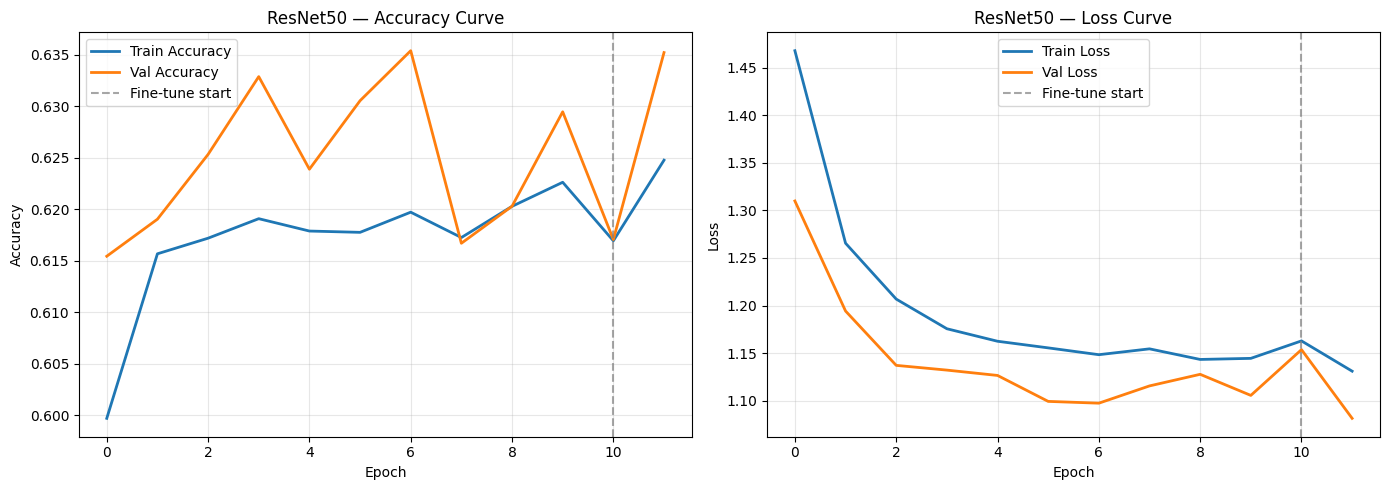

In [22]:
plot_history(ALL_HISTORIES['ResNet50'], 'ResNet50', phase_split=phase_split_rn)

Found 15835 images belonging to 5 classes.
Found 5562 images belonging to 5 classes.
174/174 ━━━━━━━━━━━━━━━━━━━━ 26s 123ms/step

  ResNet50 — Results
  Accuracy  : 0.6352
  Precision : 0.4838
  Recall    : 0.6352
  F1-Score  : 0.5333
  ROC-AUC   : 0.7165
  PR-AUC    : 0.3259
  Parameters: 24,777,605

Classification Report:
              precision    recall  f1-score   support

         CBB       0.00      0.00      0.00       282
        CBSD       0.32      0.13      0.18       569
         CGM       0.00      0.00      0.00       620
         CMD       0.33      0.15      0.21       670
     Healthy       0.67      0.98      0.80      3421

    accuracy                           0.64      5562
   macro avg       0.26      0.25      0.24      5562
weighted avg       0.48      0.64      0.53      5562



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


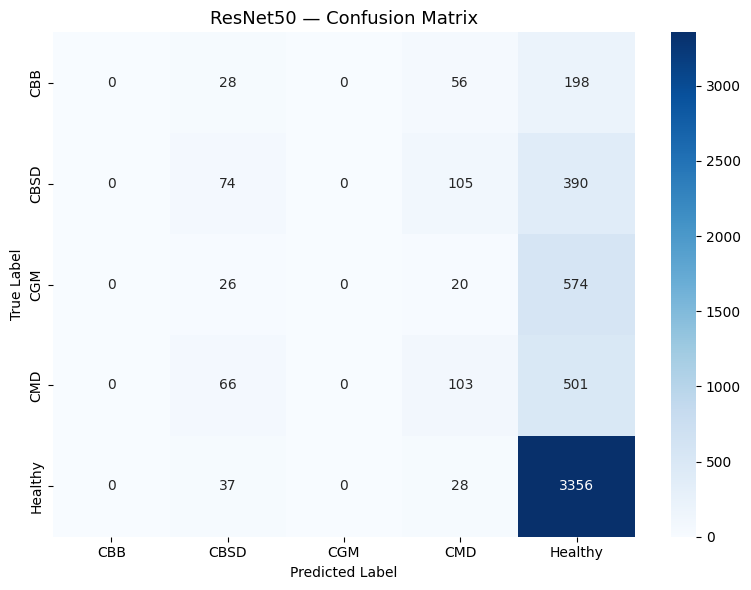

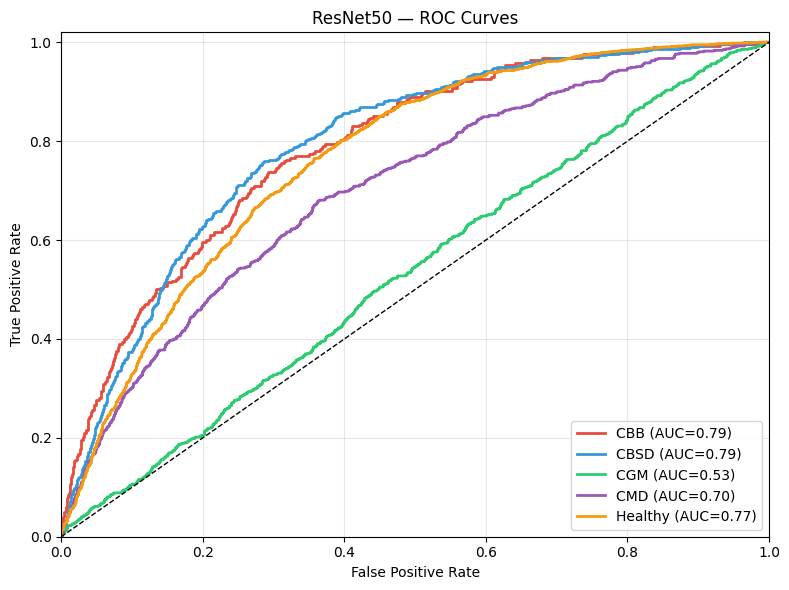

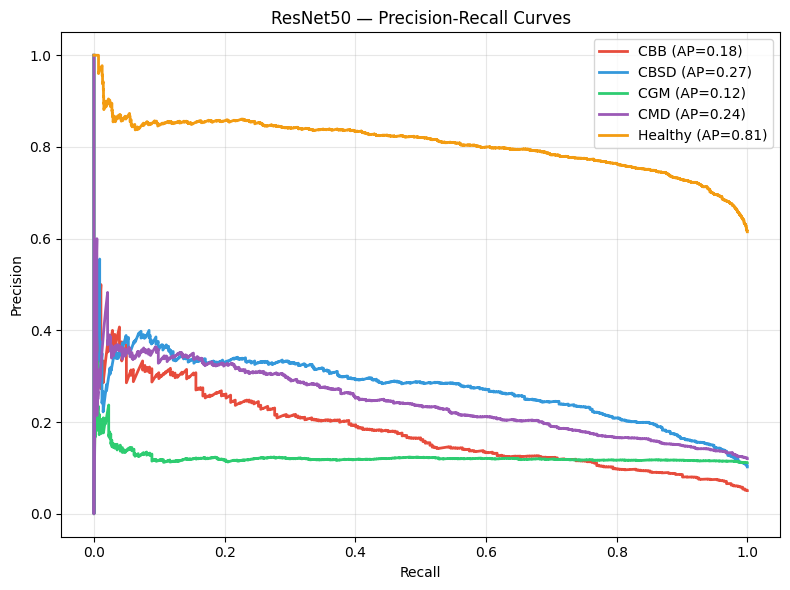

  Model Size: 224.79 MB


In [23]:
train_gen, val_gen = make_generators()
result_resnet = evaluate_model(resnet_model, val_gen, 'ResNet50')
ALL_RESULTS['ResNet50'] = result_resnet

---
## SECTION 9 — MODEL 4: InceptionV3 (Pretrained, Functional API)

In [24]:
print('Building InceptionV3...')
inception_model, inception_base = build_pretrained(InceptionV3, 'InceptionV3')
inception_model.summary()

Building InceptionV3...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "InceptionV3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_105         │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,992,677 (87.71 MB)

 Trainable params: 1,185,797 (4.52 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

In [25]:
train_gen, val_gen = make_generators()

# Phase 1
inception_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy']
)
print('InceptionV3 Phase 1: Head training...')
hist_iv_p1 = inception_model.fit(
    train_gen, epochs=10 , validation_data=val_gen,
    callbacks=get_callbacks('inception_p1'), verbose=1
)

# Phase 2: Fine-tune last 50 layers
inception_base.trainable = True
for layer in inception_base.layers[:-50]:
    layer.trainable = False

inception_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy', metrics=['accuracy']
)
print('InceptionV3 Phase 2: Fine-tuning...')
hist_iv_p2 = inception_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=get_callbacks('inception_p2'), verbose=1
)

ALL_HISTORIES['InceptionV3'] = combine_histories(hist_iv_p1, hist_iv_p2)
phase_split_iv = len(hist_iv_p1.history['accuracy'])

Found 15835 images belonging to 5 classes.
Found 5562 images belonging to 5 classes.
InceptionV3 Phase 1: Head training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.5812 - loss: 2.1779

495/495 ━━━━━━━━━━━━━━━━━━━━ 258s 486ms/step - accuracy: 0.5813 - loss: 2.1774 - val_accuracy: 0.6699 - val_loss: 1.5869 - learning_rate: 0.0010
Epoch 2/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.6441 - loss: 1.6299

495/495 ━━━━━━━━━━━━━━━━━━━━ 216s 437ms/step - accuracy: 0.6441 - loss: 1.6298 - val_accuracy: 0.6811 - val_loss: 1.3411 - learning_rate: 0.0010
Epoch 3/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.6566 - loss: 1.3715

495/495 ━━━━━━━━━━━━━━━━━━━━ 217s 438ms/step - accuracy: 0.6566 - loss: 1.3715 - val_accuracy: 0.6890 - val_loss: 1.1910 - learning_rate: 0.0010
Epoch 4/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.6610 - loss: 1.2332

495/495 ━━━━━━━━━━━━━━━━━━━━ 218s 440ms/step - accuracy: 0.6610 - loss: 1.2332 - val_accuracy: 0.6917 - val_loss: 1.1132 - learning_rate: 0.0010
Epoch 5/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 220s 444ms/step - accuracy: 0.6674 - loss: 1.1597 - val_accuracy: 0.6872 - val_loss: 1.1477 - learning_rate: 0.0010
Epoch 6/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 222s 449ms/step - accuracy: 0.6622 - loss: 1.1564 - val_accuracy: 0.6828 - val_loss: 1.0750 - learning_rate: 0.0010
Epoch 7/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 218s 440ms/step - accuracy: 0.6682 - loss: 1.1324 - val_accuracy: 0.6825 - val_loss: 1.0529 - learning_rate: 0.0010
Epoch 8/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 222s 448ms/step - accuracy: 0.6795 - loss: 1.1075 - val_accuracy: 0.6796 - val_loss: 1.1021 - learning_rate: 0.0010
Epoch 9/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 221s 447ms/step - accuracy: 0.6770 - loss: 1.1283 - val_accuracy: 0.6913 - val_loss: 1.0854 - learning_rate: 0.0010
Epoch 10/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.6743 -

495/495 ━━━━━━━━━━━━━━━━━━━━ 218s 440ms/step - accuracy: 0.6743 - loss: 1.1224 - val_accuracy: 0.6978 - val_loss: 1.0395 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.
InceptionV3 Phase 2: Fine-tuning...
Epoch 1/2
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.6600 - loss: 1.1502

495/495 ━━━━━━━━━━━━━━━━━━━━ 267s 489ms/step - accuracy: 0.6600 - loss: 1.1501 - val_accuracy: 0.7048 - val_loss: 1.0329 - learning_rate: 1.0000e-05
Epoch 2/2
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.6801 - loss: 1.0831

495/495 ━━━━━━━━━━━━━━━━━━━━ 223s 450ms/step - accuracy: 0.6801 - loss: 1.0831 - val_accuracy: 0.7086 - val_loss: 1.0120 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 2.


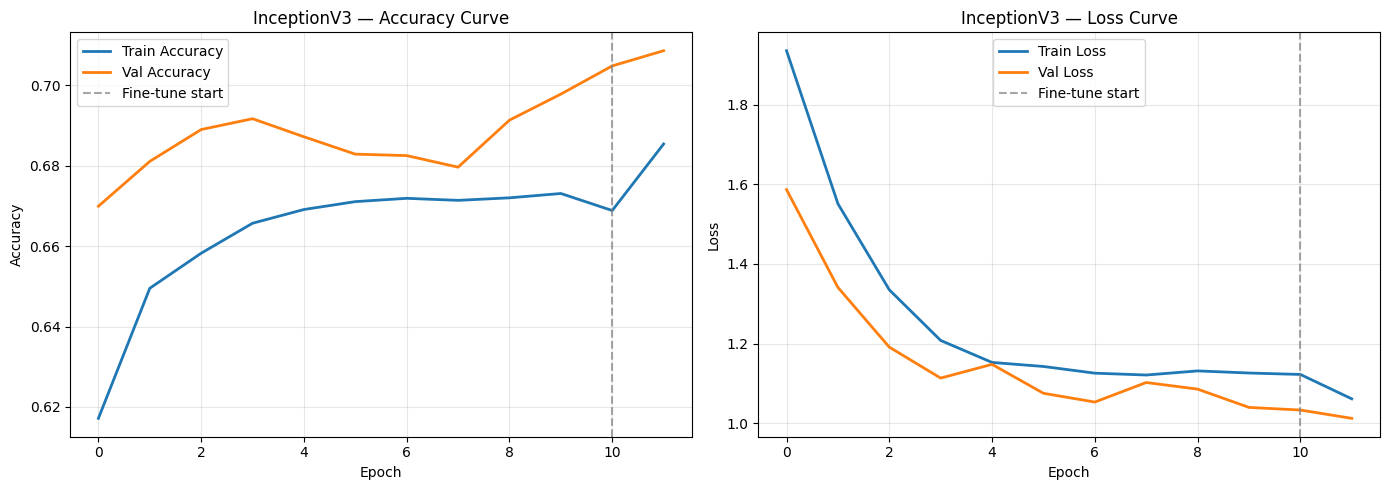

In [26]:
plot_history(ALL_HISTORIES['InceptionV3'], 'InceptionV3', phase_split=phase_split_iv)

Found 15835 images belonging to 5 classes.
Found 5562 images belonging to 5 classes.
174/174 ━━━━━━━━━━━━━━━━━━━━ 26s 107ms/step

  InceptionV3 — Results
  Accuracy  : 0.7086
  Precision : 0.7010
  Recall    : 0.7086
  F1-Score  : 0.6908
  ROC-AUC   : 0.8704
  PR-AUC    : 0.5415
  Parameters: 22,992,677

Classification Report:
              precision    recall  f1-score   support

         CBB       0.52      0.24      0.33       282
        CBSD       0.47      0.48      0.47       569
         CGM       0.57      0.21      0.31       620
         CMD       0.40      0.54      0.46       670
     Healthy       0.84      0.91      0.87      3421

    accuracy                           0.71      5562
   macro avg       0.56      0.48      0.49      5562
weighted avg       0.70      0.71      0.69      5562



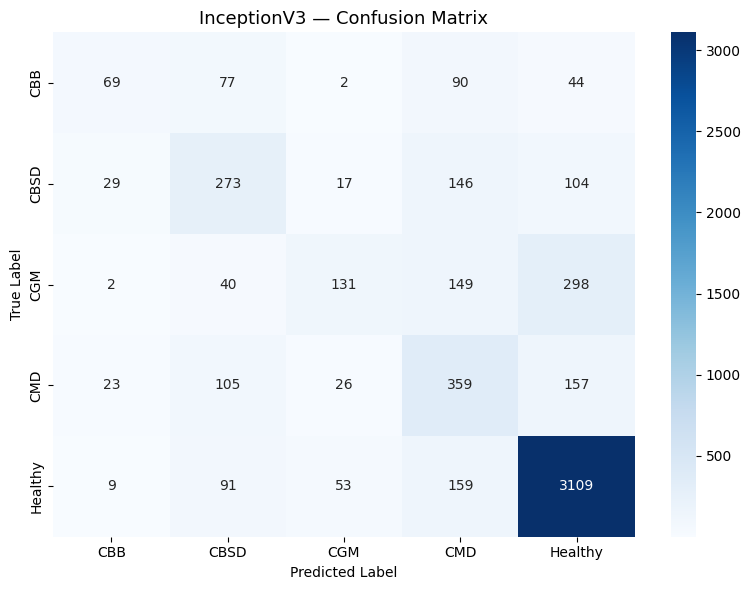

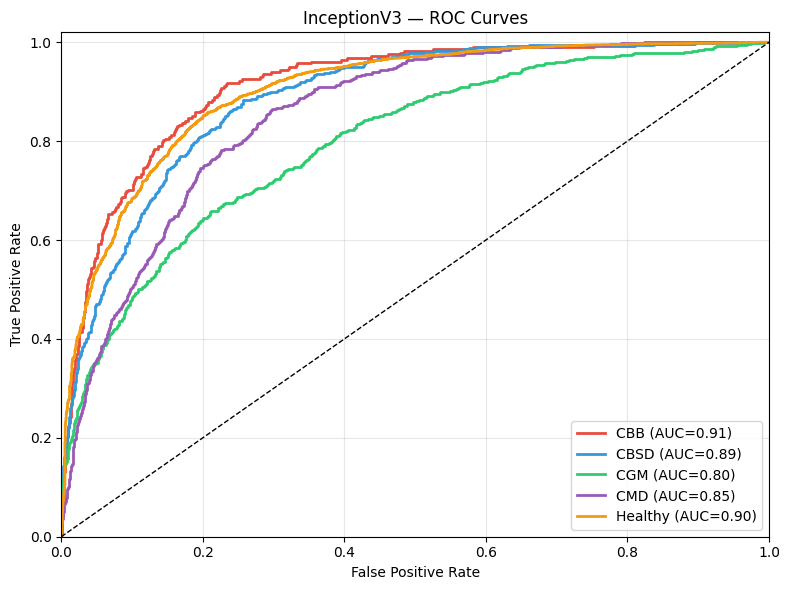

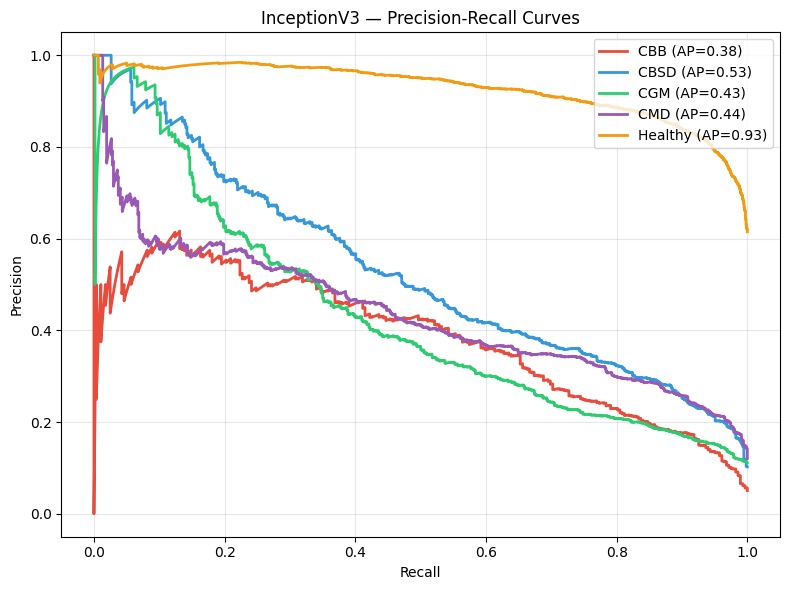

  Model Size: 152.12 MB


In [27]:
train_gen, val_gen = make_generators()
result_inception = evaluate_model(inception_model, val_gen, 'InceptionV3')
ALL_RESULTS['InceptionV3'] = result_inception

---
## SECTION 10 — Comparative Analysis (All 4 Models)

In [28]:
# ── Comparison Table ──
df = pd.DataFrame(list(ALL_RESULTS.values()))
df = df.set_index('Model')

print('\n' + '='*70)
print('  COMPARATIVE PERFORMANCE TABLE — All 4 Models')
print('='*70)
print(df.to_string())
print('='*70)


  COMPARATIVE PERFORMANCE TABLE — All 4 Models
             Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC  Parameters  Size (MB)
Model                                                                                     
Custom CNN     0.6415     0.4911  0.6415    0.5381   0.7026  0.3271   1,442,341      16.65
DenseNet121    0.7481     0.7427  0.7481    0.7376   0.8995  0.6160   7,699,013      44.82
ResNet50       0.6352     0.4838  0.6352    0.5333   0.7165  0.3259  24,777,605     224.79
InceptionV3    0.7086     0.7010  0.7086    0.6908   0.8704  0.5415  22,992,677     152.12


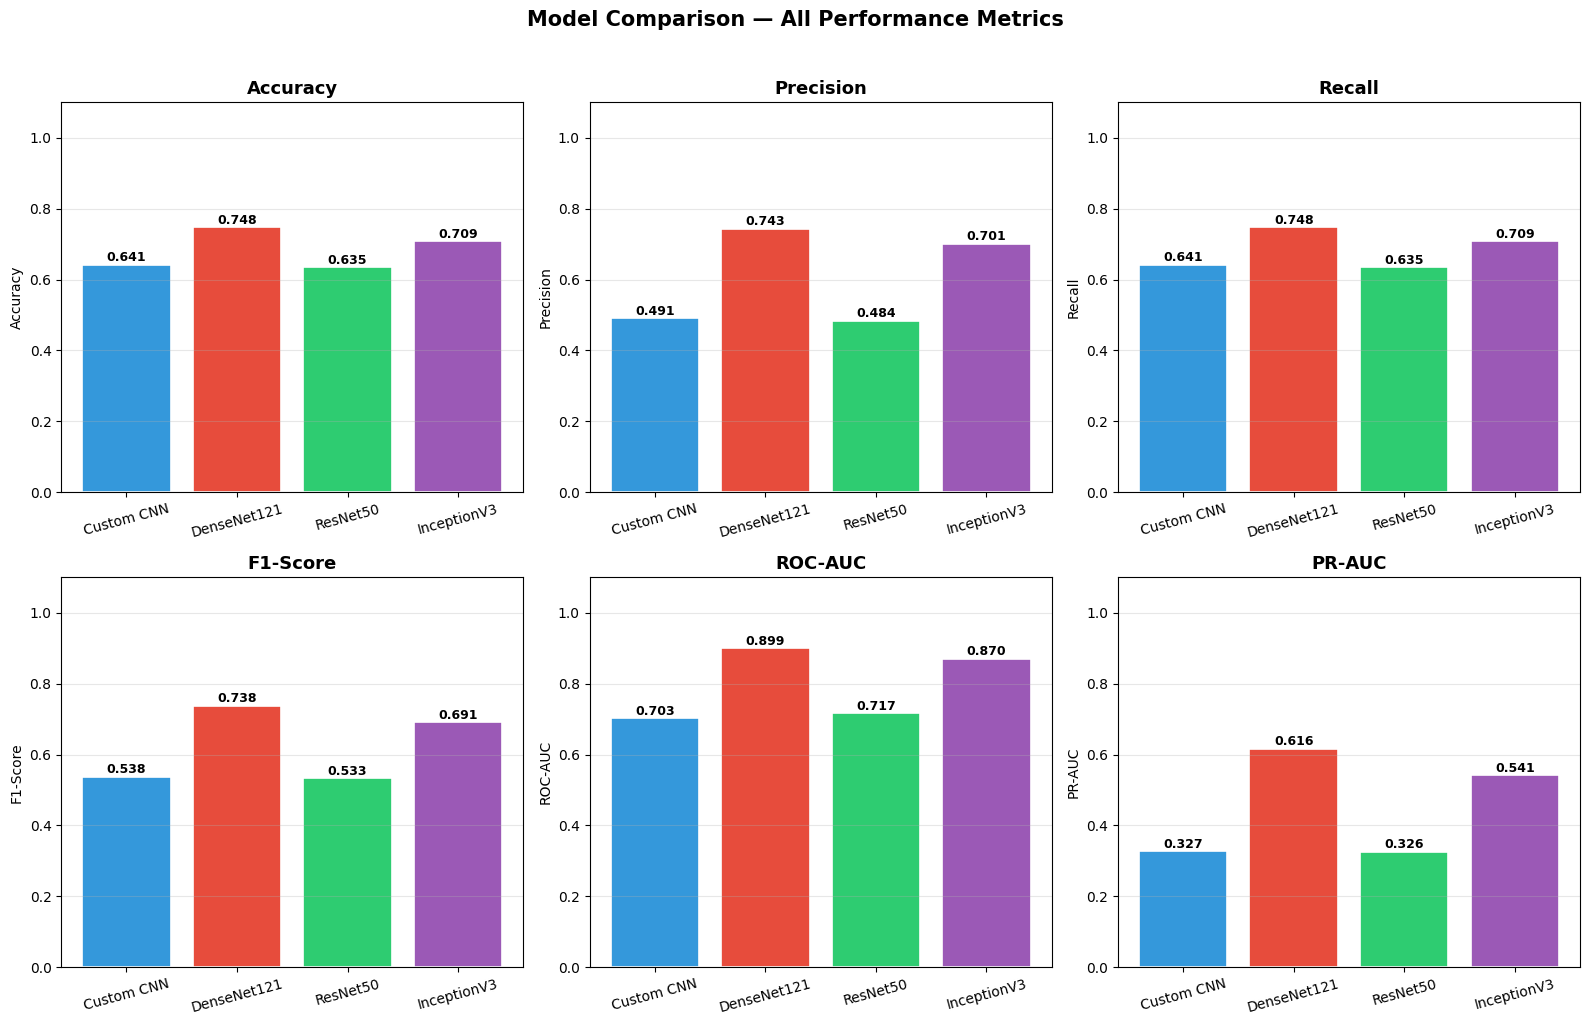

In [29]:
# ── Bar Chart Comparison ──
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
model_names = list(ALL_RESULTS.keys())
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, metric in zip(axes.flat, metrics_to_plot):
    vals = [ALL_RESULTS[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white', linewidth=1.2)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric); ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison — All Performance Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

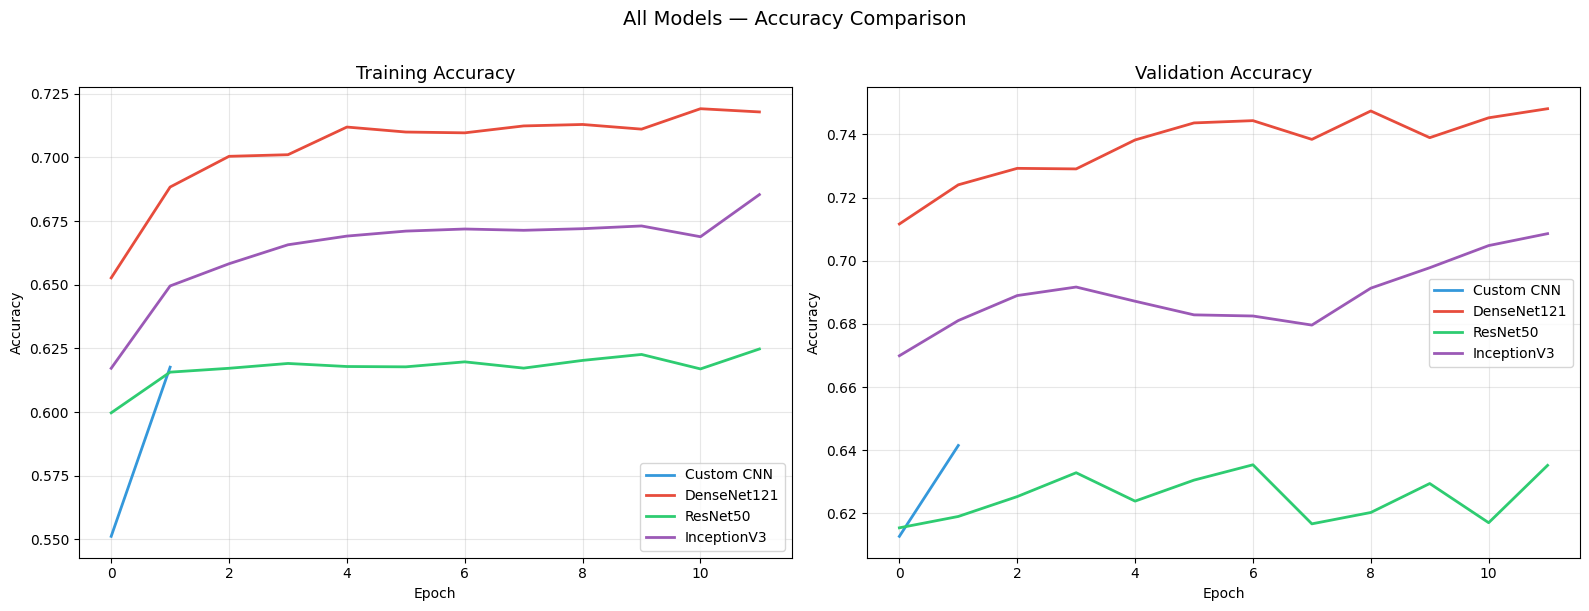

In [30]:
# ── Training Accuracy Comparison (all 4 on same plot) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'Custom CNN':'#3498db','DenseNet121':'#e74c3c','ResNet50':'#2ecc71','InceptionV3':'#9b59b6'}

for name, h in ALL_HISTORIES.items():
    axes[0].plot(h['accuracy'],     label=name, color=colors[name], linewidth=2)
    axes[1].plot(h['val_accuracy'], label=name, color=colors[name], linewidth=2)

for ax, title in zip(axes, ['Training Accuracy', 'Validation Accuracy']):
    ax.set_title(title, fontsize=13); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('All Models — Accuracy Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

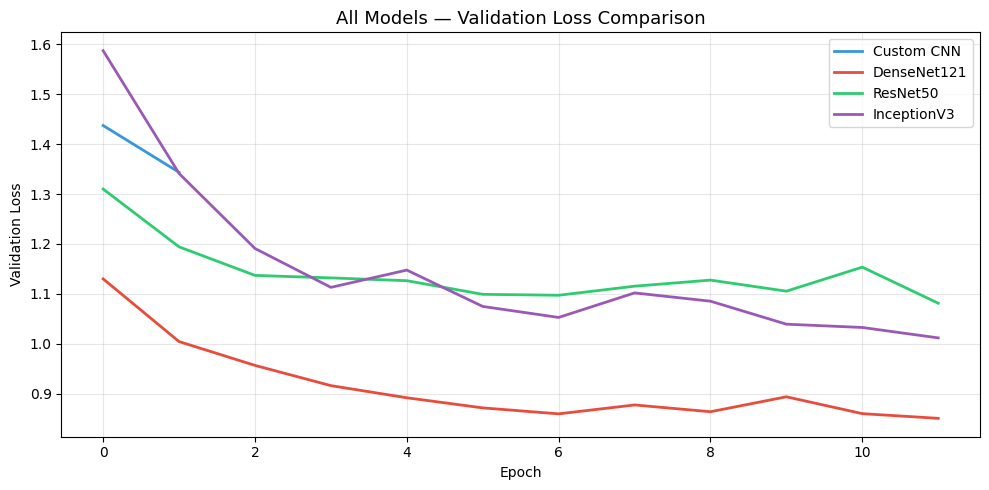

In [31]:
# ── Validation Loss Comparison ──
plt.figure(figsize=(10, 5))
for name, h in ALL_HISTORIES.items():
    plt.plot(h['val_loss'], label=name, color=colors[name], linewidth=2)
plt.title('All Models — Validation Loss Comparison', fontsize=13)
plt.xlabel('Epoch'); plt.ylabel('Validation Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# ── Deployment Suitability Table ──
deploy_data = {
    'Model'          : ['Custom CNN', 'DenseNet121', 'ResNet50', 'InceptionV3'],
    'Web Application': ['✅ Suitable', '✅ Suitable', '✅ Suitable', '✅ Suitable'],
    'Mobile Devices' : ['✅ Feasible', '⚠️ Heavy', '⚠️ Heavy', '⚠️ Heavy'],
    'Edge / Embedded': ['✅ Best fit', '❌ Too large', '❌ Too large', '⚠️ Marginal'],
    'Notes'          : [
        'Smallest model; fastest inference',
        'Dense connections; high accuracy but memory-heavy',
        'Residual blocks; strong generalisation',
        'Multi-scale features; good for fine-grained diseases'
    ]
}
deploy_df = pd.DataFrame(deploy_data).set_index('Model')
print('\nDeployment Suitability Assessment')
print(deploy_df.to_string())


Deployment Suitability Assessment
            Web Application Mobile Devices Edge / Embedded                                                 Notes
Model                                                                                                           
Custom CNN       ✅ Suitable     ✅ Feasible      ✅ Best fit                     Smallest model; fastest inference
DenseNet121      ✅ Suitable       ⚠️ Heavy     ❌ Too large     Dense connections; high accuracy but memory-heavy
ResNet50         ✅ Suitable       ⚠️ Heavy     ❌ Too large                Residual blocks; strong generalisation
InceptionV3      ✅ Suitable       ⚠️ Heavy     ⚠️ Marginal  Multi-scale features; good for fine-grained diseases


In [33]:
# ── Final Summary ──
best_model = max(ALL_RESULTS, key=lambda k: ALL_RESULTS[k]['Accuracy'])
best_acc   = ALL_RESULTS[best_model]['Accuracy']

print('\n' + '='*60)
print('  FINAL SUMMARY')
print('='*60)
print(f'  Student ID   : 20EGCO1427')
print(f'  Dataset      : Cassava Leaf Disease (5 classes)')
print(f'  Test size    : {TEST_SIZE} | Random state: {RANDOM_STATE}')
print()
for name, r in ALL_RESULTS.items():
    print(f'  {name:<15} Acc={r["Accuracy"]:.4f}  F1={r["F1-Score"]:.4f}  '
          f'ROC={r["ROC-AUC"]:.4f}  Params={r["Parameters"]}')
print()
print(f'  Best Model   : {best_model} (Accuracy: {best_acc:.4f})')
print('='*60)


  FINAL SUMMARY
  Student ID   : 20EGCO1427
  Dataset      : Cassava Leaf Disease (5 classes)
  Test size    : 0.26 | Random state: 27

  Custom CNN      Acc=0.6415  F1=0.5381  ROC=0.7026  Params=1,442,341
  DenseNet121     Acc=0.7481  F1=0.7376  ROC=0.8995  Params=7,699,013
  ResNet50        Acc=0.6352  F1=0.5333  ROC=0.7165  Params=24,777,605
  InceptionV3     Acc=0.7086  F1=0.6908  ROC=0.8704  Params=22,992,677

  Best Model   : DenseNet121 (Accuracy: 0.7481)
